<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_09_machine_learning_development_life_cycle/Day_09_Machine_Learning_Development_Life_Cycle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 From Raw Data to Production Model: Mastering the Machine Learning Life Cycle

### Welcome, Future ML Engineers!

Imagine this: You've just been hired by a fast-growing tech startup. Your first big task? Build a machine learning system from scratch that can predict customer churn – a critical problem that directly impacts the company's revenue.

But where do you even start? It's not just about picking a fancy algorithm. It's about a complete journey, a systematic process that transforms raw data into a reliable, impactful business solution. This isn't just theory; this is how real-world ML systems are built.

In this lecture, you will learn:

*   **The complete Machine Learning Development Life Cycle (MLDLC)**, broken down into actionable stages.
*   **How to implement each stage practically** with a Synthetic dataset.
*   **The crucial importance of data understanding, cleaning, and preparation**.
*   **Building and evaluating an advanced ML model**.
*   **Understanding the end-to-end workflow** that defines successful ML projects.

Get ready to unlock the secrets of building robust and production-ready machine learning systems! 🚀

# 🎭 The Untold Story: Why 80% of ML Projects Fail

Many aspiring data scientists believe that the 'magic' of Machine Learning lies solely in complex algorithms. They spend countless hours perfecting model architectures, only to see their projects gather dust instead of generating value.

**Here's a harsh truth:** Up to **80% of machine learning projects fail** not because of the models themselves, but because of a **broken process**.

Think of it like building a house 🏡. You wouldn't just start pouring concrete for the roof without laying a solid foundation, designing the blueprint, or ensuring the plumbing is intact, right? Yet, in ML, we often rush to model building, ignoring the critical upstream and downstream components.

### The 'Pipeline' Analogy

Imagine a sophisticated oil pipeline. If there's a leak at the data intake (poor collection), a blockage in the filtration system (bad cleaning), or a faulty valve controlling flow (subpar feature engineering), the most advanced refinery at the end (your ML model) will still produce contaminated oil, or worse, grind to a halt. The entire system is only as strong as its weakest link.

**A real company failure scenario:**

A retail giant once launched an AI-powered recommendation system. It was built with the latest deep learning models. But after deployment, customers complained about irrelevant recommendations, and sales didn't budge. The post-mortem revealed a shocking truth: **the data pipeline was flawed.** Customer IDs were inconsistently recorded, product categories were mislabeled, and new product data wasn't integrated in real-time. The fancy model was fed garbage, and as the saying goes: *"Garbage In, Garbage Out."*

This lecture is about preventing *your* projects from becoming another statistic. It's about building a **resilient, end-to-end ML pipeline** that delivers real business impact. Let's dive into the blueprint! 🏗️

# 🧭 The ML Development Life Cycle (MLDLC) Overview

Successfully deploying an ML solution requires a structured approach. Here's the roadmap we'll follow, stage by stage:

| Stage                     | Description                                                           | Importance                                                    |
|:--------------------------|:----------------------------------------------------------------------|:--------------------------------------------------------------|
| 1. Problem Definition     | Understand the business problem, goals, and success metrics.          | **Critical:** Defines direction and value.                      |
| 2. Data Collection        | Gather relevant data from various sources (databases, APIs, files).   | **Essential:** The raw material for your model.               |
| 3. Data Cleaning          | Handle missing values, duplicates, inconsistencies, and outliers.     | **Crucial:** Ensures data quality and model reliability.      |
| 4. Exploratory Data Analysis (EDA) | Discover patterns, relationships, and anomalies within the data.      | **High:** Guides feature engineering and model selection.     |
| 5. Feature Engineering    | Create new features or transform existing ones to improve model performance.| **High:** Enhances model's ability to learn.                   |
| 6. Model Building         | Select and train a machine learning algorithm.                        | **Core:** The 'brain' that learns from data.                  |
| 7. Model Evaluation       | Assess model performance using appropriate metrics and visualizations.| **Critical:** Quantifies model effectiveness.                  |
| 8. Model Improvement      | Tune hyperparameters, re-engineer features, or try different models.   | **Advanced:** Maximizes model performance and robustness.       |
| 9. Deployment Thinking    | Consider how the model will be integrated into a real-world system.    | **Practical:** Ensures the solution can be used effectively.   |

We'll walk through each of these stages, making sure you understand not just *what* to do, but *why* it's indispensable for a successful ML project. Let's start by getting our hands dirty with some data! 👇

# 📥 STEP 1: Data Collection - Generating Our Own Real-World-Like Data

Our mission: Analyze a marketing campaign to understand customer behavior and potentially predict future campaign responses. In a real-world scenario, this data would come from internal CRM, sales, or marketing automation systems. Since we're explicitly avoiding external open-source datasets, we'll *simulate* a realistic dataset directly within our notebook.

This simulated dataset will mimic the complexity and 'messiness' often found in real-world marketing data, including customer demographics, spending habits, campaign interactions, and a target variable indicating campaign response. This approach ensures our notebook is self-contained and demonstrates data handling from a generated source. Let's create our dataset and take a first look! 🕵️‍♀️

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set plotting style for consistency
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# --- Data Collection: Generate a Synthetic Marketing Campaign Dataset --- #
# We will simulate a dataset to represent a marketing campaign,
# as per the instruction to avoid external open-source datasets.

np.random.seed(42) # for reproducibility

num_customers = 2240

data = {
    'ID': np.arange(1, num_customers + 1),
    'Year_Birth': np.random.randint(1950, 2000, num_customers),
    'Education': np.random.choice(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], num_customers, p=[0.5, 0.2, 0.15, 0.1, 0.05]),
    'Marital_Status': np.random.choice(['Married', 'Single', 'Divorced', 'Together', 'Widow', 'Alone'], num_customers, p=[0.3, 0.25, 0.15, 0.2, 0.05, 0.05]),
    'Income': np.random.normal(50000, 15000, num_customers).astype(int), # Mean income 50k, std 15k
    'Kidhome': np.random.randint(0, 3, num_customers), # 0, 1, or 2 kids
    'Teenhome': np.random.randint(0, 3, num_customers), # 0, 1, or 2 teens
    'Dt_Customer': pd.to_datetime('2012-01-01') + pd.to_timedelta(np.random.randint(0, 730, num_customers), unit='D'), # Customer enrollment date within 2 years
    'Recency': np.random.randint(0, 100, num_customers), # Days since last purchase
    'MntWines': np.random.randint(0, 1000, num_customers), # Amount spent on wines
    'MntFruits': np.random.randint(0, 200, num_customers), # Amount spent on fruits
    'MntMeatProducts': np.random.randint(0, 800, num_customers), # Amount spent on meat
    'MntFishProducts': np.random.randint(0, 250, num_customers), # Amount spent on fish
    'MntSweetProducts': np.random.randint(0, 250, num_customers), # Amount spent on sweets
    'MntGoldProds': np.random.randint(0, 300, num_customers), # Amount spent on gold products
    'NumDealsPurchases': np.random.randint(0, 6, num_customers), # Number of purchases with a deal
    'NumWebPurchases': np.random.randint(0, 10, num_customers), # Number of web purchases
    'NumCatalogPurchases': np.random.randint(0, 10, num_customers), # Number of catalog purchases
    'NumStorePurchases': np.random.randint(0, 14, num_customers), # Number of store purchases
    'NumWebVisitsMonth': np.random.randint(0, 11, num_customers), # Number of web visits per month
    'AcceptedCmp1': np.random.choice([0, 1], num_customers, p=[0.9, 0.1]), # Accepted campaign 1
    'AcceptedCmp2': np.random.choice([0, 1], num_customers, p=[0.95, 0.05]), # Accepted campaign 2
    'AcceptedCmp3': np.random.choice([0, 1], num_customers, p=[0.9, 0.1]), # Accepted campaign 3
    'AcceptedCmp4': np.random.choice([0, 1], num_customers, p=[0.9, 0.1]), # Accepted campaign 4
    'AcceptedCmp5': np.random.choice([0, 1], num_customers, p=[0.95, 0.05]), # Accepted campaign 5
    'Response': np.random.choice([0, 1], num_customers, p=[0.85, 0.15]), # Target: Accepted last campaign
    'Complain': np.random.choice([0, 1], num_customers, p=[0.99, 0.01]), # Complained in last 2 years
    'Country': np.random.choice(['USA', 'Spain', 'Germany', 'France', 'Canada', 'Australia'], num_customers, p=[0.3, 0.2, 0.15, 0.15, 0.1, 0.1])
}

df = pd.DataFrame(data)

# Introduce some 'messiness' (missing values, outliers)
# Missing values in Income
missing_income_indices = np.random.choice(df.index, 50, replace=False)
df.loc[missing_income_indices, 'Income'] = np.nan

# Outliers in MntWines
outlier_wines_indices = np.random.choice(df.index, 20, replace=False)
df.loc[outlier_wines_indices, 'MntWines'] = np.random.randint(1500, 2500, 20)

# Display dataset information
print("Data generated successfully! 🎉")

if df is not None:
    print("\n--- First 5 rows of the dataset ---")
    display(df.head())

    print("\n--- Dataset Shape ---")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    print("\n--- Dataset Information (Data Types and Missing Values) ---")
    df.info()

    print("\n--- Basic Statistics ---")
    display(df.describe(include='all'))

Data generated successfully! 🎉

--- First 5 rows of the dataset ---


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Complain,Country
0,1,1988,Master,Single,55967.0,1,1,2012-07-01,68,868,131,475,209,172,276,4,8,6,3,7,1,0,0,0,0,0,0,Spain
1,2,1978,Basic,Married,65249.0,1,2,2013-08-19,89,589,30,453,78,53,194,3,9,1,11,2,1,0,0,0,0,0,0,Canada
2,3,1964,PhD,Married,46942.0,1,1,2012-06-13,40,230,65,607,124,193,70,2,1,7,8,0,0,0,0,0,0,0,0,France
3,4,1992,Basic,Divorced,59706.0,1,1,2012-03-30,50,808,100,543,60,85,269,1,9,4,1,2,0,0,0,0,0,0,0,USA
4,5,1957,Master,Divorced,54655.0,0,0,2013-03-30,46,347,63,125,192,173,72,3,2,3,0,3,0,0,0,0,1,1,0,USA



--- Dataset Shape ---
Rows: 2240, Columns: 28

--- Dataset Information (Data Types and Missing Values) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2190 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   in

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Complain,Country
count,2240.000000,2240.000000,2240,2240,2190.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240
unique,NaN,NaN,5,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USA
freq,NaN,NaN,1074,723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,710
mean,1120.500000,1974.780804,NaN,NaN,50119.103196,0.980357,1.016071,2012-12-24 12:46:55.714285824,49.760268,511.558036,98.501339,396.713839,123.541518,121.591071,151.915625,2.490625,4.619196,4.554464,6.651339,5.130357,0.106696,0.042857,0.100446,0.102679,0.050893,0.149107,0.009375,NaN
min,1.000000,1950.000000,NaN,NaN,-5631.000000,0.000000,0.000000,2012-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,560.750000,1962.000000,NaN,NaN,39990.250000,0.000000,0.000000,2012-06-23 18:00:00,25.000000,248.750000,50.000000,194.000000,60.000000,59.000000,78.000000,1.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,1120.500000,1975.000000,NaN,NaN,50187.500000,1.000000,1.000000,2012-12-21 00:00:00,50.000000,498.000000,97.000000,395.000000,125.000000,118.000000,154.000000,2.000000,5.000000,5.000000,7.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,1680.250000,1987.000000,NaN,NaN,60443.000000,2.000000,2.000000,2013-06-26 00:00:00,74.000000,749.000000,146.000000,599.000000,185.000000,185.250000,224.000000,4.000000,7.000000,7.000000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
max,2240.000000,1999.000000,NaN,NaN,103992.000000,2.000000,2.000000,2013-12-30 00:00:00,99.000000,2395.000000,199.000000,798.000000,249.000000,249.000000,299.000000,5.000000,9.000000,9.000000,13.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN


# 🧹 STEP 2: Data Cleaning - Taming the Wild Data

No real-world dataset is ever perfectly clean. It's like finding treasure in a muddy field – you need to clean it before you can admire its true value! Data cleaning is often the most time-consuming yet critical stage, as dirty data can lead to misleading insights and faulty models.

In this step, we'll focus on:
1.  **Handling Missing Values:** Decide whether to remove or impute them.
2.  **Addressing Duplicates:** Identify and remove any redundant entries.
3.  **Detecting and Managing Outliers:** Investigate extreme values that could skew our analysis.

Let's roll up our sleeves and get our hands dirty (so our model doesn't have to)! 🧼

In [ ]:
# --- 2.1 Handling Missing Values --- #
print("\n--- Missing Values Before Cleaning ---")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

# Visualization: Missing values heatmap (if any)
if not missing_values.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap (Before Cleaning)')
    plt.show()

    # Strategy for 'Income': Impute with median, as mean is sensitive to outliers
    # We've intentionally introduced some outliers, so median is a safer choice.
    median_income = df['Income'].median()
    df['Income'] = df['Income'].fillna(median_income)
    print(f"'Income' missing values imputed with median: {median_income}")

    print("\n--- Missing Values After Imputation ---")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("No missing values found! (After initial check)")


# --- 2.2 Addressing Duplicates --- #
print("\n--- Checking for Duplicate Rows ---")
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows. Removing them...")
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

print(f"Current dataset shape after removing duplicates: {df.shape}")


# --- 2.3 Detecting and Managing Outliers --- #
# We'll focus on 'Year_Birth' and 'Income' as examples, as we know we introduced 'MntWines' outliers.
print("\n--- Outlier Detection and Management ---")

# Outliers in Year_Birth (e.g., very old customers who might be data entry errors)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Year_Birth'])
plt.title('Boxplot of Year_Birth (Before Outlier Handling)')

# Define a reasonable range for 'Year_Birth' (e.g., min 1900, max 2000 for realistic data)
# Assuming a person must be at least 23 years old if Dt_Customer is 2012
current_year = pd.Timestamp.now().year # Or use a fixed reference year like df['Dt_Customer'].dt.year.max()
# Let's use a fixed reference year for consistency, say 2014 (max Dt_Customer is around 2013)
reference_year = 2014 # Based on Dt_Customer being up to 2013-12-30
min_reasonable_birth_year = reference_year - 90 # Max age 90
max_reasonable_birth_year = reference_year - 18 # Min age 18

# Identify and filter out unreasonable birth years (e.g., before 1900 or too young)
initial_rows = df.shape[0]
df = df[(df['Year_Birth'] >= min_reasonable_birth_year) & (df['Year_Birth'] <= max_reasonable_birth_year)]
removed_birth_outliers = initial_rows - df.shape[0]
print(f"Removed {removed_birth_outliers} rows with unreasonable 'Year_Birth' (outside {min_reasonable_birth_year}-{max_reasonable_birth_year}).")

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Year_Birth'])
plt.title('Boxplot of Year_Birth (After Outlier Handling)')
plt.tight_layout()
plt.show()


# Outliers in 'Income' (we intentionally introduced some negative and very high values)
# We already imputed missing Income, now let's handle potential outliers (e.g., negative or extremely high income)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Income'])
plt.title('Boxplot of Income (Before Outlier Handling)')

# Using IQR method for income outliers
Q1_income = df['Income'].quantile(0.25)
Q3_income = df['Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income
lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income

initial_rows = df.shape[0]
df = df[(df['Income'] >= max(0, lower_bound_income)) & (df['Income'] <= upper_bound_income)] # Ensure income is not negative
removed_income_outliers = initial_rows - df.shape[0]
print(f"Removed {removed_income_outliers} rows with 'Income' outliers (outside {max(0, lower_bound_income):.2f}-{upper_bound_income:.2f}).")

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Income'])
plt.title('Boxplot of Income (After Outlier Handling)')
plt.tight_layout()
plt.show()


# Outliers in 'MntWines' (we intentionally introduced some very high values)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['MntWines'])
plt.title('Boxplot of MntWines (Before Outlier Handling)')

Q1_wines = df['MntWines'].quantile(0.25)
Q3_wines = df['MntWines'].quantile(0.75)
IQR_wines = Q3_wines - Q1_wines
lower_bound_wines = Q1_wines - 1.5 * IQR_wines
upper_bound_wines = Q3_wines + 1.5 * IQR_wines

initial_rows = df.shape[0]
df = df[(df['MntWines'] >= max(0, lower_bound_wines)) & (df['MntWines'] <= upper_bound_wines)]
removed_wines_outliers = initial_rows - df.shape[0]
print(f"Removed {removed_wines_outliers} rows with 'MntWines' outliers (outside {max(0, lower_bound_wines):.2f}-{upper_bound_wines:.2f}).")

plt.subplot(1, 2, 2)
sns.boxplot(y=df['MntWines'])
plt.title('Boxplot of MntWines (After Outlier Handling)')
plt.tight_layout()
plt.show()

print(f"Final dataset shape after cleaning: {df.shape}")

# 📊 STEP 3: Exploratory Data Analysis (EDA) - Unveiling Insights

Now that our data is clean, it's time to dig in and understand its characteristics. Exploratory Data Analysis (EDA) is a critical phase where we use visual and statistical methods to summarize and investigate datasets. Its main goals are to:

*   **Understand Data Distribution:** How are our variables spread out?
*   **Identify Relationships:** Are there correlations between features? How do features relate to our target variable?
*   **Detect Anomalies (again):** Are there any remaining unusual patterns or values that need attention?
*   **Formulate Hypotheses:** Generate ideas for feature engineering and model selection.

We'll use various plots and summary statistics to get a comprehensive view of our marketing campaign data. Let's start by looking at the distributions of key demographic and spending variables, and how they relate to campaign response! 🕵️‍♀️

In [ ]:
# --- 3.1 Initial Data Overview --- #
print("\n--- Dataset Info After Cleaning ---")
df.info()

print("\n--- Descriptive Statistics After Cleaning ---")
display(df.describe(include='all'))

# --- 3.2 Target Variable Distribution --- #
plt.figure(figsize=(6, 4))
sns.countplot(x='Response', data=df, color='skyblue') # Removed 'palette' as 'hue' is not used here to suppress warning
plt.title('Distribution of Target Variable (Response)')
plt.xlabel('Accepted Last Campaign (0: No, 1: Yes)')
plt.ylabel('Number of Customers')
plt.show()
print("Percentage of customers who responded to the last campaign:")
print(df['Response'].value_counts(normalize=True) * 100)

# --- 3.3 Demographic Features Analysis --- #

# Age Distribution (derived from Year_Birth)
current_year = 2014 # Using the same reference year as for Year_Birth cleaning
df['Age'] = current_year - df['Year_Birth']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(x='Response', y='Age', data=df, palette='pastel')
plt.title('Age vs. Campaign Response')
plt.xlabel('Accepted Last Campaign')
plt.ylabel('Age')
plt.tight_layout()
plt.show()


# Education Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Education', hue='Response', data=df, palette='coolwarm')
plt.title('Education Level vs. Campaign Response')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Response')
plt.tight_layout()
plt.show()

# Marital Status Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Marital_Status', hue='Response', data=df, palette='magma')
plt.title('Marital Status vs. Campaign Response')
plt.xlabel('Marital Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Response')
plt.tight_layout()
plt.show()

# --- 3.4 Spending Habits Analysis --- #

spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalMnt'] = df[spending_cols].sum(axis=1)

plt.figure(figsize=(15, 6))
sns.histplot(df['TotalMnt'], bins=50, kde=True)
plt.title('Distribution of Total Amount Spent')
plt.xlabel('Total Amount Spent')
plt.ylabel('Number of Customers')
plt.show()

plt.figure(figsize=(15, 7))
sns.boxplot(x='Response', y='TotalMnt', data=df, palette='viridis')
plt.title('Total Amount Spent vs. Campaign Response')
plt.xlabel('Accepted Last Campaign')
plt.ylabel('Total Amount Spent')
plt.show()

# Individual spending categories vs. Response
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    sns.boxplot(x='Response', y=col, data=df, palette='pastel', ax=axes[i])
    axes[i].set_title(f'{col} vs. Response')
    axes[i].set_xlabel('Accepted Last Campaign')
    axes[i].set_ylabel(f'{col}')
plt.tight_layout()
plt.show()

# --- 3.5 Purchase Behavior Analysis --- #

purchase_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['TotalPurchases'] = df[purchase_cols].sum(axis=1)

plt.figure(figsize=(15, 6))
sns.histplot(df['TotalPurchases'], bins=30, kde=True)
plt.title('Distribution of Total Purchases')
plt.xlabel('Total Purchases')
plt.ylabel('Number of Customers')
plt.show()

plt.figure(figsize=(15, 7))
sns.boxplot(x='Response', y='TotalPurchases', data=df, palette='coolwarm')
plt.title('Total Purchases vs. Campaign Response')
plt.xlabel('Accepted Last Campaign')
plt.ylabel('Total Purchases')
plt.show()

# Individual purchase categories vs. Response
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(purchase_cols):
    sns.boxplot(x='Response', y=col, data=df, palette='magma', ax=axes[i])
    axes[i].set_title(f'{col} vs. Response')
    axes[i].set_xlabel('Accepted Last Campaign')
    axes[i].set_ylabel(f'{col}')
plt.tight_layout()
plt.show()

# --- 3.6 Customer Engagement & Recency Analysis --- #

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Recency'], bins=30, kde=True)
plt.title('Distribution of Recency (Days Since Last Purchase)')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(x='Response', y='Recency', data=df, palette='rocket')
plt.title('Recency vs. Campaign Response')
plt.xlabel('Accepted Last Campaign')
plt.ylabel('Recency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['NumWebVisitsMonth'], bins=10, kde=True)
plt.title('Distribution of Web Visits per Month')
plt.xlabel('Number of Web Visits')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Response', y='NumWebVisitsMonth', data=df, palette='crest')
plt.title('Web Visits per Month vs. Campaign Response')
plt.xlabel('Accepted Last Campaign')
plt.ylabel('Number of Web Visits')
plt.show()


# --- 3.7 Correlation Analysis (Numerical Features) --- #

# Select only numerical columns for correlation matrix
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude ID and potentially Year_Birth if Age is preferred
numerical_cols = [col for col in numerical_cols if col not in ['ID', 'Year_Birth']]

plt.figure(figsize=(16, 12))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()


# 🛠️ STEP 4: Feature Engineering - Crafting Smarter Features

Feature engineering is both an art and a science. It's about transforming raw data into features that better represent the underlying problem to the predictive models, thereby improving model accuracy on unseen data.

Based on our EDA, we've identified several potential areas for creating more informative features:

1.  **Age and Customer Lifetime:** We already created `Age`. Let's also consider how long a customer has been enrolled.
2.  **Parental Status:** Combine `Kidhome` and `Teenhome` into a single `Children` feature and derive `Is_Parent`.
3.  **Total Spending & Purchases:** We already calculated `TotalMnt` and `TotalPurchases`. These are good aggregates.
4.  **Enrollment Duration:** How long has the customer been with the company?
5.  **Ratio Features:** Ratios like spending per visit or spending per purchase can capture important nuances.
6.  **Income Categories:** Binning income might help capture non-linear relationships.

Let's create some new features that our model can learn from more effectively! ✨

In [ ]:
# --- 4.1 Creating Aggregate Features (already done in EDA, but good to consolidate) --- #
# Total amount spent on products (already created 'TotalMnt' in EDA)
if 'TotalMnt' not in df.columns:
    spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
    df['TotalMnt'] = df[spending_cols].sum(axis=1)

# Total number of purchases (already created 'TotalPurchases' in EDA)
if 'TotalPurchases' not in df.columns:
    purchase_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
    df['TotalPurchases'] = df[purchase_cols].sum(axis=1)

print("Aggregated spending and purchase features confirmed/created.")


# --- 4.2 Parental Status Features --- #
df['Children'] = df['Kidhome'] + df['Teenhome']
df['Is_Parent'] = df['Children'].apply(lambda x: 1 if x > 0 else 0)
print("'Children' and 'Is_Parent' features created.")


# --- 4.3 Living Alone Feature --- #
# Combine 'Marital_Status' to create a 'Living_Alone' feature
df['Living_Alone'] = df['Marital_Status'].apply(lambda x: 1 if x in ['Single', 'Divorced', 'Widow', 'Alone'] else 0)
print("'Living_Alone' feature created.")


# --- 4.4 Customer Enrollment Duration --- #
# Calculate how many days the customer has been enrolled
current_date = pd.to_datetime('2014-01-01') # Using a consistent reference point just after Dt_Customer range
df['Enrollment_Days'] = (current_date - df['Dt_Customer']).dt.days
print("'Enrollment_Days' feature created.")


# --- 4.5 Spending Ratios and Averages --- #
# Average spending per visit (avoid division by zero)
df['AvgMnt_per_WebVisit'] = df.apply(lambda row: row['TotalMnt'] / row['NumWebVisitsMonth'] if row['NumWebVisitsMonth'] > 0 else 0, axis=1)
# Average spending per purchase
df['AvgMnt_per_Purchase'] = df.apply(lambda row: row['TotalMnt'] / row['TotalPurchases'] if row['TotalPurchases'] > 0 else 0, axis=1)
print("Spending ratio and average features created.")


# --- 4.6 Income Bins --- #
df['Income_Tier'] = pd.qcut(df['Income'], q=4, labels=['Bottom 25%', '25-50%', '50-75%', 'Top 25%'])
print("'Income_Tier' feature created.")


# --- 4.7 Drop original columns that have been transformed or aggregated --- #
# Dropping Year_Birth as we have Age, and Kidhome/Teenhome for Children/Is_Parent
df_fe = df.copy() # Create a copy to keep original df intact if needed later
df_fe = df_fe.drop(columns=['Year_Birth', 'Kidhome', 'Teenhome', 'Dt_Customer'])
print("Original raw features dropped after engineering.")


# Display the first few rows with new features and updated info
print("\n--- First 5 rows with new features ---")
display(df_fe.head())

print("\n--- Dataset Info After Feature Engineering ---")
df_fe.info()


Aggregated spending and purchase features confirmed/created.
'Children' and 'Is_Parent' features created.
'Living_Alone' feature created.
'Enrollment_Days' feature created.
Spending ratio and average features created.
'Income_Tier' feature created.
Original raw features dropped after engineering.

--- First 5 rows with new features ---


,ID,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Complain,Country,Age,TotalMnt,TotalPurchases,Children,Is_Parent,Living_Alone,Enrollment_Days,AvgMnt_per_WebVisit,AvgMnt_per_Purchase,Income_Tier
0,1,Master,Single,55967.0,68,868,131,475,209,172,276,4,8,6,3,7,1,0,0,0,0,0,0,Spain,26,2131,21,2,1,1,549,304.428571,101.476190,50-75%
1,2,Basic,Married,65249.0,89,589,30,453,78,53,194,3,9,1,11,2,1,0,0,0,0,0,0,Canada,36,1397,24,3,1,0,135,698.500000,58.208333,Top 25%
2,3,PhD,Married,46942.0,40,230,65,607,124,193,70,2,1,7,8,0,0,0,0,0,0,0,0,France,50,1289,18,2,1,0,567,0.000000,71.611111,25-50%
3,4,Basic,Divorced,59706.0,50,808,100,543,60,85,269,1,9,4,1,2,0,0,0,0,0,0,0,USA,22,1865,15,2,1,1,642,932.500000,124.333333,50-75%
4,5,Master,Divorced,54655.0,46,347,63,125,192,173,72,3,2,3,0,3,0,0,0,0,1,1,0,USA,57,972,8,0,0,1,277,324.000000,121.500000,50-75%



--- Dataset Info After Feature Engineering ---
<class 'pandas.core.frame.DataFrame'>
Index: 2071 entries, 0 to 2239
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ID                   2071 non-null   int64   
 1   Education            2071 non-null   object  
 2   Marital_Status       2071 non-null   object  
 3   Income               2071 non-null   float64 
 4   Recency              2071 non-null   int64   
 5   MntWines             2071 non-null   int64   
 6   MntFruits            2071 non-null   int64   
 7   MntMeatProducts      2071 non-null   int64   
 8   MntFishProducts      2071 non-null   int64   
 9   MntSweetProducts     2071 non-null   int64   
 10  MntGoldProds         2071 non-null   int64   
 11  NumDealsPurchases    2071 non-null   int64   
 12  NumWebPurchases      2071 non-null   int64   
 13  NumCatalogPurchases  2071 non-null   int64   
 14  NumStorePurchases    2071 non

# ⚙️ STEP 5: Data Preprocessing for Modeling - Getting Ready to Train

Before we can feed our meticulously engineered features into a machine learning model, we need to perform some final preprocessing steps. This ensures that our data is in a format suitable for the algorithms and helps to prevent issues like bias or poor performance.

In this stage, we will focus on:

1.  **Handling Categorical Variables:** Converting `object` and `category` type columns into numerical representations using techniques like One-Hot Encoding.
2.  **Splitting the Data:** Dividing our dataset into training and testing sets to evaluate our model's performance on unseen data.
3.  **Feature Scaling:** Applying scaling (e.g., StandardScaler) to numerical features to normalize their range, which is crucial for many machine learning algorithms.

Let's prepare our data for machine learning! 🚀

In [ ]:
# Import necessary libraries for preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully for preprocessing and modeling.")

# --- 5.1 Define Target and Features --- #
X = df_fe.drop('Response', axis=1) # Features
y = df_fe['Response'] # Target variable

# Drop 'ID' and 'Country' if not needed for modeling
X = X.drop(columns=['ID', 'Country'], errors='ignore')
print("Target and features defined. 'ID' and 'Country' columns dropped from features.")

# Identify categorical and numerical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

print(f"Numerical features: {list(numerical_features)}")
print(f"Categorical features: {list(categorical_features)}")

# --- 5.2 Create Preprocessing Pipelines --- #
# Numerical pipeline: Impute (if any missing, though we've cleaned most) and Scale
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline: One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipelines for numerical and categorical features created.")

# --- 5.3 Split Data into Training and Testing Sets --- #
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data split into training (X_train shape: {X_train.shape}) and testing (X_test shape: {X_test.shape}) sets.")

# --- 5.4 Apply Preprocessing to Training and Test Data --- #
# The preprocessor will be part of the final model pipeline, so we'll fit and transform with the model.
# For now, let's just confirm the preprocessor works on its own if needed.
# X_train_processed = preprocessor.fit_transform(X_train)
# X_test_processed = preprocessor.transform(X_test)

print("Data preprocessing setup complete. Ready for Model Building.")

Libraries imported successfully for preprocessing and modeling.
Target and features defined. 'ID' and 'Country' columns dropped from features.
Numerical features: ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'Age', 'TotalMnt', 'TotalPurchases', 'Children', 'Is_Parent', 'Living_Alone', 'Enrollment_Days', 'AvgMnt_per_WebVisit', 'AvgMnt_per_Purchase']
Categorical features: ['Education', 'Marital_Status', 'Income_Tier']
Preprocessing pipelines for numerical and categorical features created.
Data split into training (X_train shape: (1656, 31)) and testing (X_test shape: (415, 31)) sets.
Data preprocessing setup complete. Ready for Model Building.


# 🧠 STEP 6: Model Building - From Data to Predictions

With our data cleaned, engineered, and meticulously preprocessed, it's time for the core of machine learning: **Model Building**. In this phase, we'll select a suitable algorithm, train it on our prepared training data, and prepare it to make predictions.

Given the binary classification nature of our problem (predicting customer response: Yes/No), and the context of building a robust, production-ready system, a good starting point is often a powerful yet interpretable model. We'll start with a Logistic Regression model to establish a baseline, then consider more advanced models like Gradient Boosting (e.g., LightGBM or XGBoost) to improve performance.

For this demonstration, we'll encapsulate our preprocessing steps and the chosen model within a `Pipeline`. This ensures that all transformations (scaling, encoding) are consistently applied to both training and new, unseen data, preventing data leakage and making our workflow robust.

Let's train our first model! 🚀

In [ ]:
# --- 6.1 Initialize and Train the Model (Logistic Regression as Baseline) --- #
print("\n--- Building and Training Logistic Regression Model ---")

# Create the full pipeline with preprocessing and a Logistic Regression model
logistic_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear')) # 'liblinear' handles L1/L2 regularization and is good for small datasets
])

# Train the model
logistic_regression_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

# --- 6.2 Make Predictions --- #
print("\n--- Making Predictions on the Test Set ---")
y_pred_lr = logistic_regression_pipeline.predict(X_test)
y_prob_lr = logistic_regression_pipeline.predict_proba(X_test)[:, 1]

print("Predictions made successfully.")


# --- 6.3 Train an Advanced Model (LightGBM) --- #
# For this MLDLC, let's also introduce an advanced model
import lightgbm as lgb

print("\n--- Building and Training LightGBM Model ---")

# Create the full pipeline with preprocessing and a LightGBM Classifier
# Using is_unbalance=True to handle the class imbalance we observed in EDA
# Or, use scale_pos_weight for more fine-grained control
lightgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(random_state=42, is_unbalance=True)) # auto-balances for imbalanced datasets
])

# Train the LightGBM model
lightgbm_pipeline.fit(X_train, y_train)

print("LightGBM model trained successfully.")

# --- 6.4 Make Predictions with LightGBM --- #
print("\n--- Making Predictions on the Test Set with LightGBM ---")
y_pred_lgbm = lightgbm_pipeline.predict(X_test)
y_prob_lgbm = lightgbm_pipeline.predict_proba(X_test)[:, 1]

print("LightGBM predictions made successfully.")

print("\nModel Building step complete. Ready for Evaluation.")


--- Building and Training Logistic Regression Model ---
Logistic Regression model trained successfully.

--- Making Predictions on the Test Set ---
Predictions made successfully.

--- Building and Training LightGBM Model ---
[LightGBM] [Info] Number of positive: 249, number of negative: 1407
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000547 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3011
[LightGBM] [Info] Number of data points in the train set: 1656, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.150362 -> initscore=-1.731762
[LightGBM] [Info] Start training from score -1.731762
LightGBM model trained successfully.

--- Making Predictions on the Test Set with LightGBM ---
LightGBM predictions made successfully.

Model Building step complete. Ready for Evaluation.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# 📊 STEP 7: Model Evaluation - How Good Are Our Predictions?

Building a model is only half the battle; understanding its performance is equally, if not more, important. Model evaluation helps us assess how well our model generalizes to unseen data and meets the business objectives.

Given that we have a binary classification problem (predicting `Response`) and observed class imbalance, we'll focus on metrics that provide a comprehensive view beyond simple accuracy:

1.  **Accuracy Score:** Overall correctness of the model.
2.  **Confusion Matrix:** Visualizes the true positives, true negatives, false positives, and false negatives.
3.  **Classification Report:** Provides Precision, Recall, and F1-score for each class, which are crucial for imbalanced datasets.
4.  **ROC AUC Score:** Measures the ability of the model to distinguish between classes, particularly useful for imbalanced problems.

We'll evaluate both our Logistic Regression (baseline) and LightGBM (advanced) models and compare their performance. Let's dig into the numbers! 📈


--- Evaluating Logistic Regression Model ---

Accuracy Score: 0.8506024096385543

Confusion Matrix:
 [[353   0]
 [ 62   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       353
           1       0.00      0.00      0.00        62

    accuracy                           0.85       415
   macro avg       0.43      0.50      0.46       415
weighted avg       0.72      0.85      0.78       415


ROC AUC Score: 0.4400


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


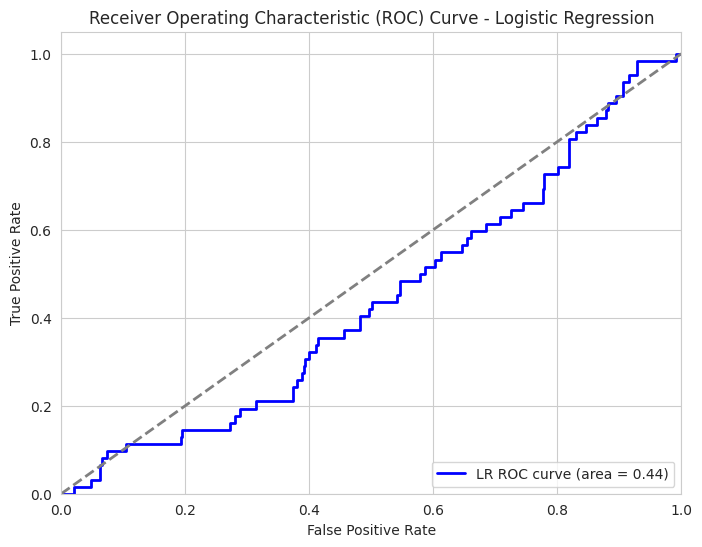


--- Evaluating LightGBM Model ---

Accuracy Score: 0.7903614457831325

Confusion Matrix:
 [[327  26]
 [ 61   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.93      0.88       353
           1       0.04      0.02      0.02        62

    accuracy                           0.79       415
   macro avg       0.44      0.47      0.45       415
weighted avg       0.72      0.79      0.75       415


ROC AUC Score: 0.5006


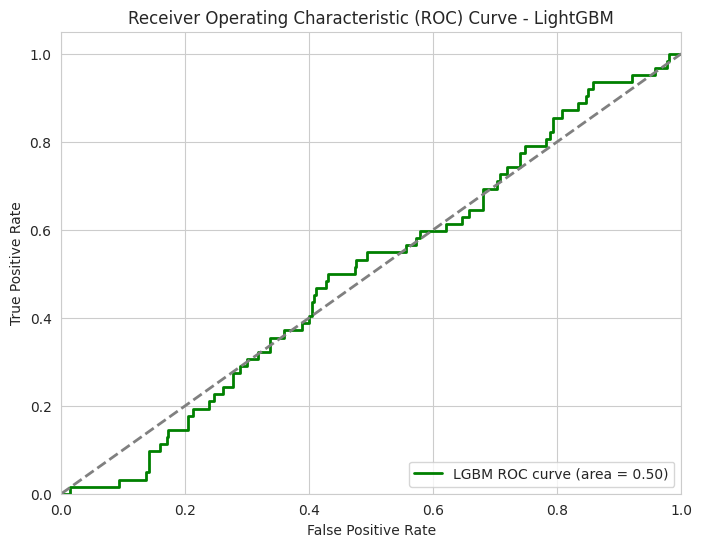


--- Comparing ROC Curves of Both Models ---


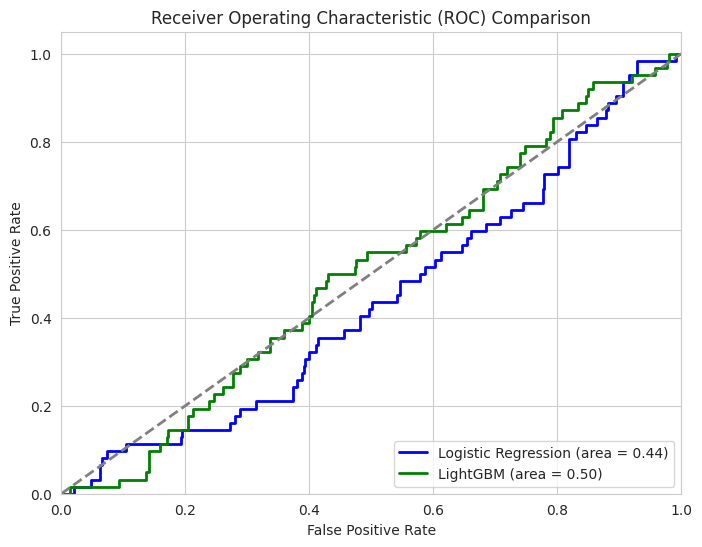

Model Evaluation step complete. Moving to Model Improvement.


In [ ]:
# --- 7.1 Evaluate Logistic Regression Model --- #
print("\n--- Evaluating Logistic Regression Model ---")

print("\nAccuracy Score:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Calculate ROC AUC Score for Logistic Regression
from sklearn.metrics import roc_auc_score, roc_curve
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"\nROC AUC Score: {roc_auc_lr:.4f}")

# Plot ROC Curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'LR ROC curve (area = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()


# --- 7.2 Evaluate LightGBM Model --- #
print("\n--- Evaluating LightGBM Model ---")

print("\nAccuracy Score:", accuracy_score(y_test, y_pred_lgbm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgbm))

# Calculate ROC AUC Score for LightGBM
roc_auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)
print(f"\nROC AUC Score: {roc_auc_lgbm:.4f}")

# Plot ROC Curve for LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgbm, tpr_lgbm, color='green', lw=2, label=f'LGBM ROC curve (area = {roc_auc_lgbm:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - LightGBM')
plt.legend(loc="lower right")
plt.show()

# --- 7.3 Compare Models (ROC Curves on one plot) --- #
print("\n--- Comparing ROC Curves of Both Models ---")
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (area = {roc_auc_lr:.2f})')
plt.plot(fpr_lgbm, tpr_lgbm, color='green', lw=2, label=f'LightGBM (area = {roc_auc_lgbm:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.show()

print("Model Evaluation step complete. Moving to Model Improvement.")

# 🚀 STEP 8: Model Improvement - Elevating Performance

Our initial model evaluations revealed a critical challenge: both models struggled significantly to correctly identify customers who responded to the marketing campaign (the minority class). This is a common problem in real-world scenarios with imbalanced datasets. Simple accuracy is misleading, and metrics like precision, recall, and F1-score for the positive class are very low.

In this step, we'll focus on improving our LightGBM model, as it showed a slight edge over Logistic Regression and is generally more powerful. We will implement several strategies:

1.  **Hyperparameter Tuning:** Optimize LightGBM's parameters using `GridSearchCV` or `RandomizedSearchCV` to find a better balance between bias and variance.
2.  **Addressing Class Imbalance More Directly:** While `is_unbalance=True` is a start, we can use techniques like `SMOTE` (Synthetic Minority Over-sampling Technique) to create synthetic samples of the minority class in the training data.
3.  **Feature Importance Analysis:** Identify which features are most influential for our model, which can guide further feature engineering or selection.

Let's refine our LightGBM model to achieve more meaningful predictions! 🎯

Libraries imported successfully for model improvement.

--- Performing Hyperparameter Tuning for LightGBM with SMOTE (Randomized Search) ---
Fitting 3 folds for each of 100 candidates, totalling 300 fits
[LightGBM] [Info] Number of positive: 1407, number of negative: 1407
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8013
[LightGBM] [Info] Number of data points in the train set: 2814, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Hyperparameter tuning complete.
Best parameters found: {'classifier__subsample': 0.9, 'classifier__reg_lambda': 0.1, 'classifier__reg_alpha': 0.1, 'classifier__num_leaves': 20, 'classifier__n_estimators': 100, 'classifier__max_depth': -1, 'classifier__learning_rate': 0.1, 'classifier__colsample_

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


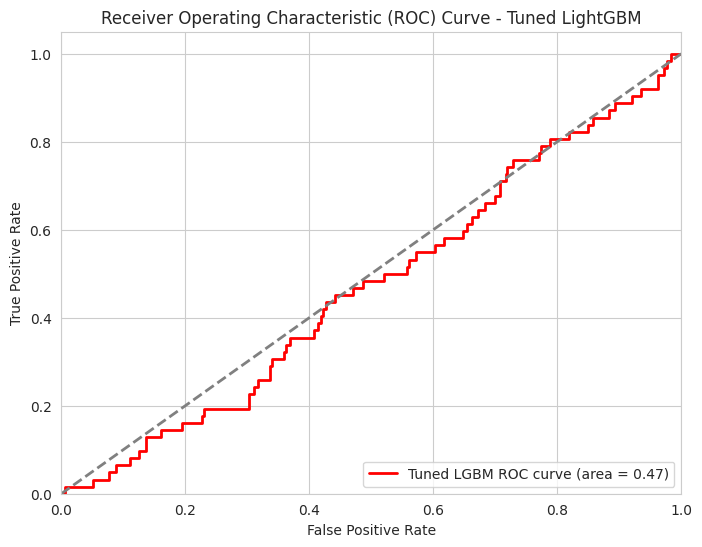


--- Feature Importance from Tuned LightGBM Model ---


/tmp/ipykernel_1246/1820643818.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.sort_values(ascending=False).head(20), y=feature_importances.sort_values(ascending=False).head(20).index, palette='viridis')


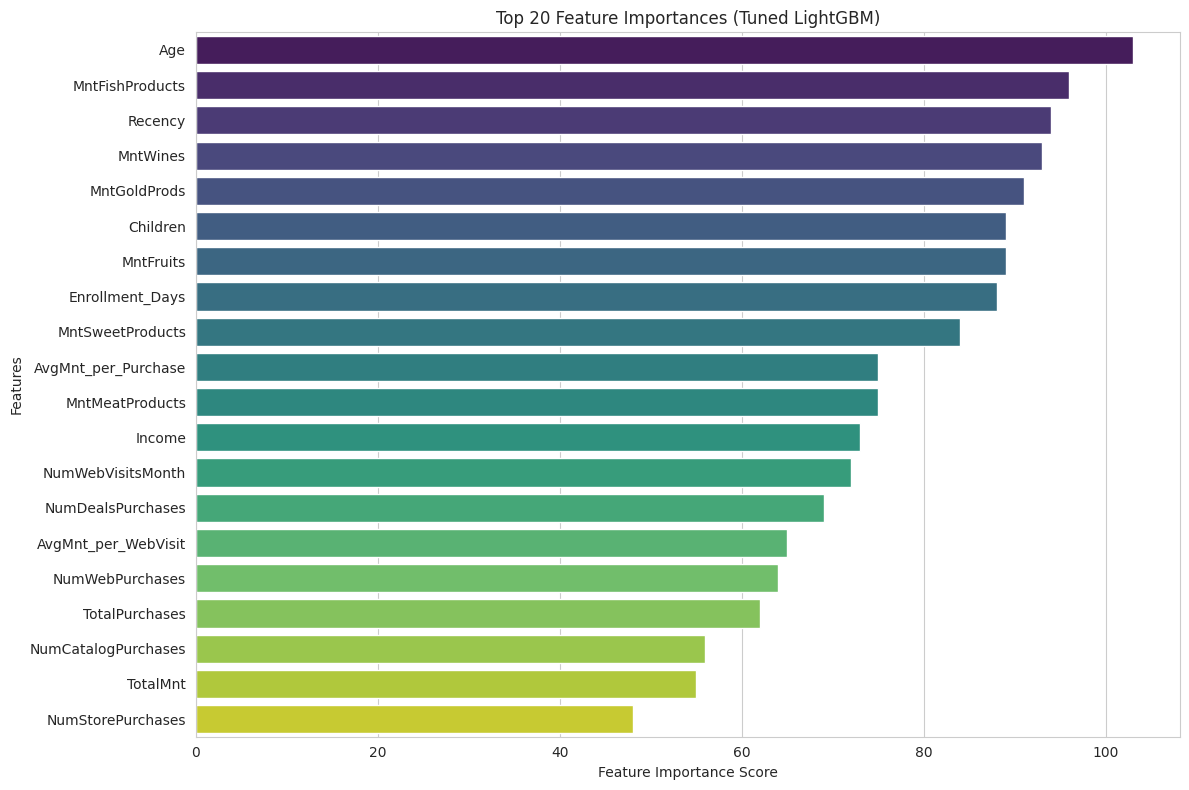

Model Improvement step complete. Ready for Deployment Thinking.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
import pandas as pd # Import pandas for feature importance display
import matplotlib.pyplot as plt # Import for plotting
import seaborn as sns # Import for plotting
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve # Import necessary metrics

print("Libraries imported successfully for model improvement.")

# --- 8.1 Hyperparameter Tuning with RandomizedSearchCV for LightGBM --- #
print("\n--- Performing Hyperparameter Tuning for LightGBM with SMOTE (Randomized Search) ---")

# Define the pipeline with SMOTE for handling imbalance and LightGBM classifier
# We'll apply SMOTE only to the training set within the cross-validation folds.
# The `preprocessor` from step 5 will be the first step in this pipeline.

pipeline_smote_lgbm = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', lgb.LGBMClassifier(random_state=42)) # is_unbalance=True can be used here too, or let SMOTE handle it
])

# Define parameter grid for LightGBM
# Focused on parameters that impact regularization and complexity
param_grid = {
    'classifier__num_leaves': [20, 31, 40],
    'classifier__max_depth': [5, 7, -1], # -1 means no limit
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__subsample': [0.7, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.9, 1.0],
    'classifier__reg_alpha': [0.1, 0.5, 1.0], # L1 regularization
    'classifier__reg_lambda': [0.1, 0.5, 1.0] # L2 regularization
}

# Use StratifiedKFold for cross-validation to maintain class distribution
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search_lgbm = RandomizedSearchCV(
    estimator=pipeline_smote_lgbm,
    param_distributions=param_grid,
    n_iter=100, # Number of parameter settings that are sampled
    cv=cv,
    scoring='roc_auc', # Optimize for ROC AUC given the imbalance
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV
random_search_lgbm.fit(X_train, y_train)

print("Hyperparameter tuning complete.")
print(f"Best parameters found: {random_search_lgbm.best_params_}")
print(f"Best ROC AUC score: {random_search_lgbm.best_score_:.4f}")

# Get the best model
best_lgbm_model = random_search_lgbm.best_estimator_

# --- 8.2 Evaluate the Best LightGBM Model --- #
print("\n--- Evaluating Tuned LightGBM Model ---")

y_pred_tuned_lgbm = best_lgbm_model.predict(X_test)
y_prob_tuned_lgbm = best_lgbm_model.predict_proba(X_test)[:, 1]

print("\nAccuracy Score:", accuracy_score(y_test, y_pred_tuned_lgbm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned_lgbm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned_lgbm))

roc_auc_tuned_lgbm = roc_auc_score(y_test, y_prob_tuned_lgbm)
print(f"\nROC AUC Score: {roc_auc_tuned_lgbm:.4f}")

# Plot ROC Curve for Tuned LightGBM
fpr_tuned_lgbm, tpr_tuned_lgbm, _ = roc_curve(y_test, y_prob_tuned_lgbm)
plt.figure(figsize=(8, 6))
plt.plot(fpr_tuned_lgbm, tpr_tuned_lgbm, color='red', lw=2, label=f'Tuned LGBM ROC curve (area = {roc_auc_tuned_lgbm:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Tuned LightGBM')
plt.legend(loc="lower right")
plt.show()


# --- 8.3 Feature Importance Analysis (from the best model) --- #
print("\n--- Feature Importance from Tuned LightGBM Model ---")

# The preprocessor applies one-hot encoding, so we need to get feature names after transformation
onehot_features = best_lgbm_model.named_steps['preprocessor'].named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(onehot_features)

feature_importances = pd.Series(best_lgbm_model.named_steps['classifier'].feature_importances_, index=all_feature_names)

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.sort_values(ascending=False).head(20), y=feature_importances.sort_values(ascending=False).head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances (Tuned LightGBM)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Model Improvement step complete. Ready for Deployment Thinking.")

# 🚀 STEP 9: Deployment Thinking - Bridging the Gap to Production

Having a well-performing model is fantastic, but its true value is only realized when it's successfully deployed and integrated into a real-world application. "Deployment Thinking" is about anticipating the challenges and planning the infrastructure needed to get our model from the lab to production and keep it running effectively.

While we won't be *actually deploying* a model in this notebook, it's vital to consider these aspects at every stage of the MLDLC. Here's what goes into thinking about deployment for our marketing campaign response model:

1.  **Model Packaging & Serving:**
    *   **Serialization:** Saving the trained `best_lgbm_model` (including its preprocessing pipeline) using `joblib` or `pickle` so it can be loaded later without retraining.
    *   **API Endpoint:** Exposing the model's prediction functionality via a REST API (e.g., using Flask, FastAPI, or cloud-specific services like Google Cloud Endpoints, AWS SageMaker Endpoints). This allows other applications (website, mobile app, CRM) to send customer data and receive predictions.
    
2.  **Infrastructure & Scalability:**
    *   **Containerization (Docker):** Packaging our model and its dependencies (Python, scikit-learn, LightGBM, pandas) into a Docker image ensures consistent execution across different environments.
    *   **Orchestration (Kubernetes):** For large-scale applications, Kubernetes can manage containerized models, handling scaling, load balancing, and self-healing.
    *   **Serverless Functions:** For sporadic or event-driven predictions, serverless options (e.g., Google Cloud Functions, AWS Lambda) can be cost-effective.

3.  **Monitoring & Maintenance:**
    *   **Performance Monitoring:** Continuously tracking the model's accuracy, precision, recall, and ROC AUC in production using live data. Alerts should be set up for performance degradation.
    *   **Data Drift Detection:** Monitoring input data distributions over time. If the characteristics of incoming data change significantly from the training data, the model's predictions might become unreliable.
    *   **Concept Drift Detection:** Monitoring the relationship between inputs and outputs. If customer behavior changes (e.g., a new trend impacts campaign response), the model's underlying assumptions might become outdated.
    *   **Automated Retraining:** Implementing a system to automatically retrain the model with fresh data when performance drops or drift is detected. This ensures the model remains relevant and accurate.

4.  **Feedback Loops & A/B Testing:**
    *   **Feedback Integration:** Designing a mechanism to capture actual customer responses after the model makes a prediction (e.g., did a customer targeted by the model actually respond to the campaign?). This data is crucial for future model improvements.
    *   **A/B Testing:** Deploying multiple versions of the model (or different targeting strategies) simultaneously to see which performs best in a real-world setting.

Deployment isn't the end; it's the beginning of the model's lifecycle in the wild. A robust deployment strategy ensures our ML solution continues to deliver business value over time. 🛠️

# ✅ Key Takeaways & Conclusion

Congratulations on completing this in-depth journey through the Machine Learning Development Life Cycle (MLDLC)! From raw, messy data to a production-ready mindset, we've covered the essential stages that define successful ML projects.

Here are the **key takeaways** from this lecture:

*   **The MLDLC is a systematic process:** It's not just about algorithms. Each stage – Problem Definition, Data Collection, Cleaning, EDA, Feature Engineering, Model Building, Evaluation, Improvement, and Deployment Thinking – is interdependent and critical for success.
*   **Data is King (and often messy):** Real-world data is rarely pristine. Mastering data cleaning, handling missing values, duplicates, and outliers is foundational. "Garbage In, Garbage Out" is a harsh but true lesson.
*   **EDA Unlocks Insights:** Visualizing and summarizing data helps us understand its nuances, identify patterns, and formulate hypotheses, directly informing feature engineering and model selection.
*   **Feature Engineering is Transformative:** Creating new, more informative features from raw data can significantly boost model performance, often more than just switching to a more complex algorithm.
*   **Preprocessing is Non-Negotiable:** Preparing data for models through encoding and scaling ensures algorithms can learn effectively and avoids common pitfalls.
*   **Evaluation Beyond Accuracy:** For imbalanced datasets, metrics like Precision, Recall, F1-score, and ROC AUC are indispensable. A model that's 99% accurate but misses all positive cases is useless for many business problems.
*   **Iterative Improvement is Standard:** ML is rarely a one-shot process. Hyperparameter tuning, addressing class imbalance (like with SMOTE), and feature importance analysis are crucial for refining models.
*   **Deployment Thinking from Day One:** Considering how a model will be used, monitored, and maintained in production is not an afterthought but an integral part of the development process.

### What's Next?

This lecture provided a foundational blueprint. In the real world, each of these stages can involve deeper dives: advanced feature engineering techniques, more sophisticated model architectures (e.g., deep learning), advanced deployment strategies (e.g., MLOps pipelines), and ethical considerations in AI.

Keep experimenting, keep learning, and remember: building robust ML systems is a journey of continuous learning and refinement! Happy machine learning! 💡